# ROP Classification: ICROP Components + Treatment

ICROP分類の3軸（Zone / Stage / Plus）と治療判断（Treatment）の4タスクモデル。
全タスクに画像 + 臨床データ（fused特徴量）を入力。

## Architecture

```
Input Image (512x512)           Clinical Features (4-dim)
       |                               |
 EfficientNet-B0                 ClinicalEncoder MLP
       |                         4 → 64 → ReLU → BN → 32
 Image Features (1280)                  |
       |                                |
       +---------- Concatenate ---------+
                      |
               Fused (1312-dim)
                      |
          +----+----+----+----+
        Zone Stage Plus Treatment
```

## タスク定義

| Task | Classes | 臨床的意義 |
|------|---------|-----------|
| Zone | I / II / III | ICROP分類: 病変の位置 |
| Stage | 0 / 1 / 2 / 3 | ICROP分類: 病変の重症度 |
| Plus | Normal / PrePlus / Plus | ICROP分類: 血管異常 |
| Treatment | No / Yes | 治療要否の判断 |

## 臨床特徴量

| Feature | Type | Preprocessing |
|---------|------|---------------|
| Sex | Binary (0/1) | No normalization |
| GA (weeks) | Continuous | Z-score (per fold) |
| BW (g) | Continuous | Z-score (per fold) |
| PMA (weeks) | Continuous | Z-score (per fold) |

## 出力先
```
outputs_icrop_treatment/
├── fold_1/best_model.pt
├── fold_2/best_model.pt
├── fold_3/best_model.pt
├── fold_4/best_model.pt
├── fold_5/best_model.pt
├── predictions.csv
└── config.json
```
**スキップ判定**: `best_model.pt` の存在を確認。再学習するには該当ファイルを削除。

In [1]:
# ==================== Environment Setup ====================
import os
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# timm for EfficientNet
import timm

# Metrics
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    cohen_kappa_score, accuracy_score, f1_score
)

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

from datetime import datetime

# Seed
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Quadro RTX 5000


In [2]:
# ==================== Configuration ====================

class Config:
    """Training configuration: ICROP (Zone/Stage/Plus) + Treatment"""

    # Paths
    DATA_ROOT = Path(r"E:\Multicenter_ROP_study")
    KUBOTA_DIR = DATA_ROOT / "Multicenter_images" / "Kubota_selection"
    EXCEL_PATH = DATA_ROOT / "multicenter_patient_data_20260127.xlsx"
    OUTPUT_DIR = Path(r"C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_icrop_treatment")

    # Model
    MODEL_NAME = "efficientnet_b0"
    PRETRAINED = True
    DROPOUT = 0.5

    # Clinical features
    N_CLINICAL_FEATURES = 4    # sex, GA, BW, PMA
    CLINICAL_EMBED_DIM = 32    # ClinicalEncoder output dim

    # Image
    IMG_SIZE = 512

    # Training
    BATCH_SIZE = 16
    NUM_WORKERS = 0
    EPOCHS = 200
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-3
    PATIENCE = 15

    # Cross-validation
    N_FOLDS = 5

    # Task weights (no AROP)
    TASK_WEIGHTS = {
        'zone': 1.0,
        'stage': 1.0,
        'plus': 1.0,
        'treatment': 1.5
    }

    # Label smoothing
    LABEL_SMOOTHING = 0.1

    # MixUp
    MIXUP_ALPHA = 0.2
    MIXUP_P = 0.5

    # Class balancing
    USE_CLASS_WEIGHTS = True
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA = 2.0
    USE_WEIGHTED_SAMPLER = False

    # Quality filter
    QUALITY_FILTER = ["Good", "Fair"]

    # Version
    VERSION = "icrop_treatment"

config = Config()
config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {config.OUTPUT_DIR}")

Output directory: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_icrop_treatment


## 1. Data Loading

In [3]:
# ==================== Load Data ====================

def load_quality_labeled_images(kubota_dir: Path) -> pd.DataFrame:
    """Load images from Kubota_selection folder."""
    data = []
    for quality in ["Good", "Fair", "Bad", "Worst"]:
        folder = kubota_dir / quality
        if not folder.exists():
            continue
        for img_path in folder.glob("*.png"):
            if img_path.stat().st_size == 0:
                continue
            filename = img_path.stem
            parts = filename.rsplit('_', 1)
            video_id = parts[0] if len(parts) >= 2 else filename
            data.append({
                "image_path": str(img_path),
                "video_id": video_id,
                "quality": quality
            })
    return pd.DataFrame(data)

def load_patient_data(excel_path: Path) -> pd.DataFrame:
    """Load and preprocess patient data including clinical features."""
    df = pd.read_excel(excel_path)

    column_mapping = {
        'video_id': df.columns[0],
        'sex': df.columns[2],       # 性別
        'ga': df.columns[3],        # GA(week)
        'bw': df.columns[4],        # BW(g)
        'pma': df.columns[5],       # PMA(week)
        'zone': df.columns[6],
        'stage': df.columns[7],
        'plus': df.columns[8],
        'aggressive_rop': df.columns[9],
        'treatment': df.columns[12],
    }
    rename_dict = {v: k for k, v in column_mapping.items()}
    df = df.rename(columns=rename_dict)

    # Encode classification labels
    df['zone_label'] = df['zone'].apply(lambda x: int(x) - 1 if pd.notna(x) and str(x).isdigit() else -1)
    df['stage_label'] = df['stage'].apply(lambda x: int(x) if pd.notna(x) and str(x).isdigit() else -1)
    
    # Plus label: Excel contains numeric values (0, 1, 2) not text
    def map_plus_label(x):
        if pd.isna(x):
            return -1
        # Handle numeric values directly
        if isinstance(x, (int, float)) and not np.isnan(x):
            val = int(x)
            if val in [0, 1, 2]:
                return val
        # Fallback: try text mapping
        text_map = {'normal': 0, 'preplus': 1, 'plus': 2, '0': 0, '1': 1, '2': 2}
        return text_map.get(str(x).lower().strip(), -1)
    
    df['plus_label'] = df['plus'].apply(map_plus_label)
    df['aggressive_rop_label'] = df['aggressive_rop'].apply(lambda x: 1 if str(x).lower().strip() in ['yes', 'y', '1', 'true'] else 0)
    df['treatment_label'] = df['treatment'].apply(lambda x: 1 if str(x).lower().strip() in ['yes', 'y', '1', 'true'] else 0)

    # Encode clinical features
    sex_map = {'male': 1, 'm': 1, '男': 1, '男性': 1, '1': 1,
               'female': 0, 'f': 0, '女': 0, '女性': 0, '2': 0, '0': 0}
    df['sex_value'] = df['sex'].apply(
        lambda x: sex_map.get(str(x).lower().strip(), np.nan) if pd.notna(x) else np.nan
    )
    df['ga_value'] = pd.to_numeric(df['ga'], errors='coerce')
    df['bw_value'] = pd.to_numeric(df['bw'], errors='coerce')
    df['pma_value'] = pd.to_numeric(df['pma'], errors='coerce')

    return df

# Load and merge
quality_df = load_quality_labeled_images(config.KUBOTA_DIR)
patient_df = load_patient_data(config.EXCEL_PATH)

dataset_df = quality_df.merge(
    patient_df[['video_id', 'zone_label', 'stage_label', 'plus_label',
                'aggressive_rop_label', 'treatment_label',
                'sex_value', 'ga_value', 'bw_value', 'pma_value']],
    on='video_id', how='left'
).dropna(subset=['zone_label'])

# Filter by quality
dataset_df = dataset_df[dataset_df['quality'].isin(config.QUALITY_FILTER)].copy()

print(f"Dataset size: {len(dataset_df)}")
print(f"Quality distribution: {dataset_df['quality'].value_counts().to_dict()}")

# Clinical data completeness
clinical_cols = ['sex_value', 'ga_value', 'bw_value', 'pma_value']
print(f"\nClinical data completeness:")
for col in clinical_cols:
    n_valid = dataset_df[col].notna().sum()
    pct = n_valid / len(dataset_df) * 100
    print(f"  {col:12s}: {n_valid:>5}/{len(dataset_df)} ({pct:.1f}%)")

# Plus label distribution check
print(f"\nPlus label distribution:")
print(dataset_df['plus_label'].value_counts().sort_index())

Dataset size: 6448
Quality distribution: {'Good': 4494, 'Fair': 1954}

Clinical data completeness:
  sex_value   :  6448/6448 (100.0%)
  ga_value    :  6448/6448 (100.0%)
  bw_value    :  6448/6448 (100.0%)
  pma_value   :  6448/6448 (100.0%)

Plus label distribution:
plus_label
-1      22
 0    5379
 1     639
 2     408
Name: count, dtype: int64


### Clinical Feature Distribution

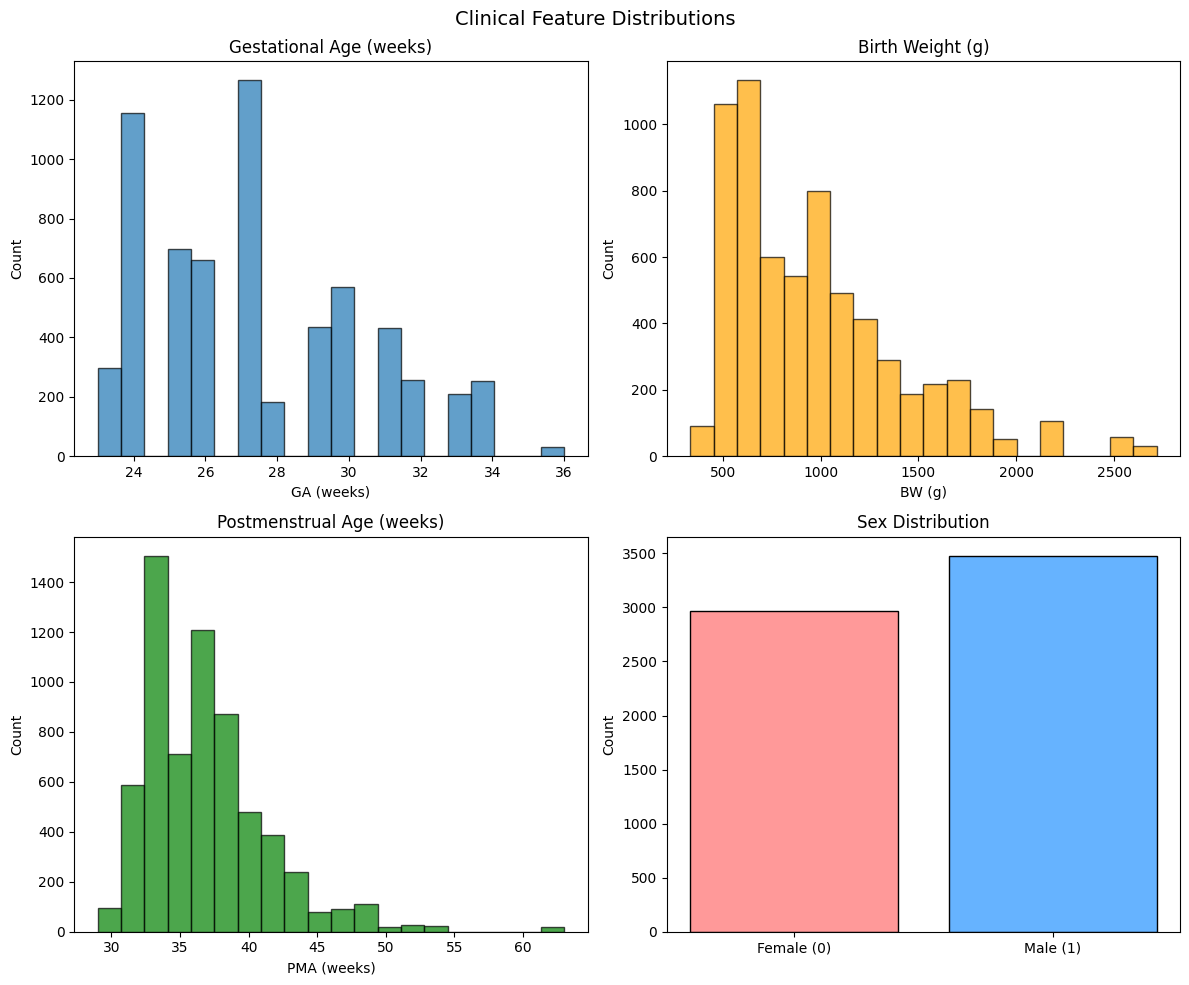

Clinical Feature Statistics:
       ga_value  bw_value  pma_value
count   6448.00   6448.00    6448.00
mean      27.37    978.04      36.82
std        3.06    451.19       4.38
min       23.00    334.00      29.00
25%       25.00    611.00      34.00
50%       27.00    919.00      36.00
75%       30.00   1245.00      39.00
max       36.00   2718.00      63.00


In [4]:
# ==================== Clinical Feature Distribution ====================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Clinical Feature Distributions', fontsize=14)

axes[0, 0].hist(dataset_df['ga_value'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Gestational Age (weeks)')
axes[0, 0].set_xlabel('GA (weeks)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(dataset_df['bw_value'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Birth Weight (g)')
axes[0, 1].set_xlabel('BW (g)')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(dataset_df['pma_value'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Postmenstrual Age (weeks)')
axes[1, 0].set_xlabel('PMA (weeks)')
axes[1, 0].set_ylabel('Count')

sex_counts = dataset_df['sex_value'].value_counts().sort_index()
axes[1, 1].bar(
    ['Female (0)', 'Male (1)'],
    [sex_counts.get(0, 0), sex_counts.get(1, 0)],
    color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[1, 1].set_title('Sex Distribution')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Basic statistics
print("Clinical Feature Statistics:")
print(dataset_df[['ga_value', 'bw_value', 'pma_value']].describe().round(2))

In [5]:
# ==================== Analyze Class Distribution ====================

def analyze_class_distribution(df: pd.DataFrame) -> Dict[str, Dict]:
    """Analyze class distribution and compute weights."""
    task_info = {
        'zone': {'col': 'zone_label', 'n_classes': 3, 'names': ['Zone I', 'Zone II', 'Zone III']},
        'stage': {'col': 'stage_label', 'n_classes': 4, 'names': ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3']},
        'plus': {'col': 'plus_label', 'n_classes': 3, 'names': ['Normal', 'PrePlus', 'Plus']},
        'treatment': {'col': 'treatment_label', 'n_classes': 2, 'names': ['No', 'Yes']},
    }

    class_weights = {}

    print("=" * 70)
    print("CLASS DISTRIBUTION AND WEIGHTS")
    print("=" * 70)

    for task, info in task_info.items():
        col = info['col']
        n_classes = info['n_classes']
        names = info['names']

        valid_mask = df[col] >= 0
        counts = df[valid_mask][col].value_counts().sort_index()
        full_counts = [counts.get(i, 0) for i in range(n_classes)]
        total = sum(full_counts)

        weights = []
        for c in full_counts:
            if c > 0:
                w = total / (n_classes * c)
            else:
                w = 1.0
            weights.append(w)

        min_w = min(weights)
        weights = [w / min_w for w in weights]

        class_weights[task] = torch.tensor(weights, dtype=torch.float32)

        print(f"\n{task.upper()}:")
        for i, (name, cnt, w) in enumerate(zip(names, full_counts, weights)):
            pct = cnt / total * 100 if total > 0 else 0
            print(f"  {name:12s}: {cnt:>5} ({pct:>5.1f}%)  weight: {w:.2f}")

    return class_weights

class_weights = analyze_class_distribution(dataset_df)

CLASS DISTRIBUTION AND WEIGHTS

ZONE:
  Zone I      :   750 ( 11.6%)  weight: 5.29
  Zone II     :  3967 ( 61.5%)  weight: 1.00
  Zone III    :  1731 ( 26.8%)  weight: 2.29

STAGE:
  Stage 0     :  2802 ( 43.6%)  weight: 1.00
  Stage 1     :  1546 ( 24.1%)  weight: 1.81
  Stage 2     :  1238 ( 19.3%)  weight: 2.26
  Stage 3     :   840 ( 13.1%)  weight: 3.34

PLUS:
  Normal      :  5379 ( 83.7%)  weight: 1.00
  PrePlus     :   639 (  9.9%)  weight: 8.42
  Plus        :   408 (  6.3%)  weight: 13.18

TREATMENT:
  No          :  5821 ( 90.3%)  weight: 1.00
  Yes         :   627 (  9.7%)  weight: 9.28


## 2. Dataset and Augmentation

In [6]:
# ==================== Augmentation ====================

def get_train_transforms(img_size: int = 512) -> A.Compose:
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Rotate(limit=180, p=0.9, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.OneOf([
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        ], p=0.7),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
        ], p=0.3),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.85, 1.0), ratio=(0.9, 1.1), p=0.4),
        A.CoarseDropout(max_holes=8, max_height=img_size//16, max_width=img_size//16, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_valid_transforms(img_size: int = 512) -> A.Compose:
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

train_transforms = get_train_transforms(config.IMG_SIZE)
valid_transforms = get_valid_transforms(config.IMG_SIZE)

In [7]:
# ==================== Dataset ====================

class ROPClinicalDataset(Dataset):
    """ROP Dataset with clinical feature support (ICROP + Treatment)."""

    def __init__(self, df: pd.DataFrame, transforms: A.Compose = None,
                 clinical_mean: np.ndarray = None, clinical_std: np.ndarray = None,
                 clinical_median: np.ndarray = None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.task_columns = {
            'zone': 'zone_label',
            'stage': 'stage_label',
            'plus': 'plus_label',
            'treatment': 'treatment_label'
        }
        self.clinical_continuous_cols = ['ga_value', 'bw_value', 'pma_value']
        self.clinical_mean = clinical_mean
        self.clinical_std = clinical_std
        self.clinical_median = clinical_median

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]

        image = cv2.imread(row['image_path'])
        if image is None:
            raise ValueError(f"Failed to load: {row['image_path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transforms:
            image = self.transforms(image=image)['image']

        labels = {}
        for task_name, col_name in self.task_columns.items():
            labels[task_name] = torch.tensor(int(row.get(col_name, -1)), dtype=torch.long)

        # Clinical features: [ga, bw, pma] (continuous) + [sex] (binary)
        continuous = np.array([row[c] for c in self.clinical_continuous_cols], dtype=np.float64)

        nan_mask = np.isnan(continuous)
        if nan_mask.any() and self.clinical_median is not None:
            continuous[nan_mask] = self.clinical_median[nan_mask]

        if self.clinical_mean is not None and self.clinical_std is not None:
            std_safe = np.where(self.clinical_std == 0, 1.0, self.clinical_std)
            continuous = (continuous - self.clinical_mean) / std_safe

        sex = row.get('sex_value', np.nan)
        sex = 0.5 if pd.isna(sex) else float(sex)

        clinical = np.concatenate([continuous, [sex]]).astype(np.float32)
        clinical = torch.tensor(clinical, dtype=torch.float32)

        return {'image': image, 'labels': labels, 'clinical': clinical, 'image_path': row['image_path']}

## 3. Model

In [8]:
# ==================== Model ====================

class ClinicalEncoder(nn.Module):
    """MLP encoder for clinical features (4-dim -> embed_dim)."""

    def __init__(self, n_features: int = 4, embed_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, embed_dim),
            nn.ReLU(),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x):
        return self.encoder(x)


class MultiTaskHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.head(x)


class ROPClinicalMultiTaskModel(nn.Module):
    """Multi-task model: ICROP (Zone/Stage/Plus) + Treatment.

    All tasks use fused features (image + clinical, 1312-dim).
    """

    TASK_CONFIG = {
        'zone': 3,
        'stage': 4,
        'plus': 3,
        'treatment': 2
    }

    def __init__(self, model_name: str = "efficientnet_b0", pretrained: bool = True,
                 dropout: float = 0.3, n_clinical: int = 4, clinical_embed_dim: int = 32):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        img_features = self.backbone.num_features

        self.clinical_encoder = ClinicalEncoder(n_clinical, clinical_embed_dim)
        fused_features = img_features + clinical_embed_dim  # 1280 + 32 = 1312

        self.heads = nn.ModuleDict()
        for task_name, num_classes in self.TASK_CONFIG.items():
            self.heads[task_name] = MultiTaskHead(fused_features, num_classes, dropout)

        print(f"Model: {model_name}, Image features: {img_features}, "
              f"Clinical embed: {clinical_embed_dim}, Fused: {fused_features}")
        print(f"  Tasks: {list(self.TASK_CONFIG.keys())}")

    def forward(self, x, clinical):
        img_feat = self.backbone(x)
        clin_feat = self.clinical_encoder(clinical)
        fused = torch.cat([img_feat, clin_feat], dim=1)

        outputs = {}
        for task, head in self.heads.items():
            outputs[task] = head(fused)
        return outputs

## 4. Loss Functions (Class-Balanced)

In [9]:
# ==================== Weighted Focal Loss ====================

class WeightedFocalLoss(nn.Module):
    """Focal Loss with class weights (alpha)."""

    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            alpha_t = alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [10]:
# ==================== Multi-Task Loss (Class-Balanced) ====================

class ClassBalancedMultiTaskLoss(nn.Module):
    """Multi-task loss with Weighted CE + Focal Loss."""

    def __init__(self, task_weights, class_weights, label_smoothing=0.1,
                 use_focal=True, focal_gamma=2.0):
        super().__init__()
        self.task_weights = task_weights
        self.class_weights = class_weights
        self.label_smoothing = label_smoothing
        self.use_focal = use_focal
        self.focal_gamma = focal_gamma

        self.focal_losses = nn.ModuleDict()
        for task, weights in class_weights.items():
            self.focal_losses[task] = WeightedFocalLoss(alpha=weights, gamma=focal_gamma)

    def forward(self, outputs, labels):
        total_loss = 0.0
        task_losses = {}

        for task_name, output in outputs.items():
            target = labels[task_name]
            mask = target >= 0

            if mask.sum() == 0:
                task_losses[task_name] = torch.tensor(0.0, device=output.device)
                continue

            output = output[mask]
            target = target[mask]

            weights = self.class_weights.get(task_name)
            if weights is not None:
                weights = weights.to(output.device)

            ce_loss = F.cross_entropy(output, target, weight=weights,
                                      label_smoothing=self.label_smoothing)

            if self.use_focal and task_name in self.focal_losses:
                focal_loss = self.focal_losses[task_name](output, target)
                loss = (ce_loss + focal_loss) / 2
            else:
                loss = ce_loss

            task_weight = self.task_weights.get(task_name, 1.0)
            task_losses[task_name] = loss
            total_loss += task_weight * loss

        return total_loss, task_losses

## 5. Training

In [11]:
# ==================== Metrics ====================

def compute_metrics(preds: Dict[str, np.ndarray], labels: Dict[str, np.ndarray]) -> Dict:
    metrics = {}

    for task_name in preds.keys():
        y_pred = preds[task_name]
        y_true = labels[task_name]

        mask = y_true >= 0
        y_pred = y_pred[mask]
        y_true = y_true[mask]

        if len(y_true) == 0:
            metrics[task_name] = {'accuracy': 0.0, 'kappa': 0.0, 'f1_macro': 0.0}
            continue

        pred_classes = y_pred.argmax(axis=1) if y_pred.ndim > 1 else y_pred

        task_metrics = {
            'accuracy': accuracy_score(y_true, pred_classes),
            'kappa': cohen_kappa_score(y_true, pred_classes, weights='quadratic'),
            'f1_macro': f1_score(y_true, pred_classes, average='macro', zero_division=0),
        }

        # Binary task metrics (Treatment only)
        if task_name == 'treatment':
            cm = confusion_matrix(y_true, pred_classes, labels=[0, 1])
            if cm.shape == (2, 2) and (cm[1, 0] + cm[1, 1]) > 0:
                task_metrics['sensitivity'] = cm[1, 1] / (cm[1, 0] + cm[1, 1])
            else:
                task_metrics['sensitivity'] = 0.0

            try:
                probs = torch.softmax(torch.tensor(y_pred), dim=1)[:, 1].numpy()
                task_metrics['auc'] = roc_auc_score(y_true, probs)
            except:
                task_metrics['auc'] = 0.0

        metrics[task_name] = task_metrics

    return metrics

In [12]:
# ==================== MixUp ====================

def mixup_data(x, clinical, y, alpha=0.2):
    """MixUp augmentation for images and clinical features."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    mixed_clinical = lam * clinical + (1 - lam) * clinical[index, :]
    y_a, y_b = y, {k: v[index] for k, v in y.items()}

    return mixed_x, mixed_clinical, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    loss_a, _ = criterion(pred, y_a)
    loss_b, _ = criterion(pred, y_b)
    return lam * loss_a + (1 - lam) * loss_b

In [13]:
# ==================== Training Loop ====================

def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, mixup_alpha=0.2, mixup_p=0.5):
    model.train()
    running_loss = 0.0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        clinical = batch['clinical'].to(device)
        labels = {k: v.to(device) for k, v in batch['labels'].items()}

        if np.random.random() < mixup_p:
            images, clinical, labels_a, labels_b, lam = mixup_data(images, clinical, labels, mixup_alpha)
            outputs = model(images, clinical)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images, clinical)
            loss, _ = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = {task: [] for task in ROPClinicalMultiTaskModel.TASK_CONFIG.keys()}
    all_labels = {task: [] for task in ROPClinicalMultiTaskModel.TASK_CONFIG.keys()}

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation", leave=False):
            images = batch['image'].to(device)
            clinical = batch['clinical'].to(device)
            labels = {k: v.to(device) for k, v in batch['labels'].items()}

            outputs = model(images, clinical)
            loss, _ = criterion(outputs, labels)
            running_loss += loss.item()

            for task in all_preds.keys():
                all_preds[task].append(outputs[task].cpu().numpy())
                all_labels[task].append(labels[task].cpu().numpy())

    for task in all_preds.keys():
        all_preds[task] = np.concatenate(all_preds[task])
        all_labels[task] = np.concatenate(all_labels[task])

    metrics = compute_metrics(all_preds, all_labels)

    return running_loss / len(dataloader), metrics, all_preds, all_labels

In [14]:
# ==================== Cross-Validation ====================

def run_cross_validation(df: pd.DataFrame, class_weights: Dict, config: Config) -> Dict:
    """Run 5-fold cross-validation: ICROP + Treatment."""
    output_dir = config.OUTPUT_DIR
    output_dir.mkdir(parents=True, exist_ok=True)

    df['stratify_target'] = df['zone_label'].astype(str) + '_' + df['stage_label'].astype(str)
    sgkf = StratifiedGroupKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=42)

    all_fold_results = []
    all_predictions = []
    clinical_continuous_cols = ['ga_value', 'bw_value', 'pma_value']
    tasks_and_cols = [('zone', 'zone_label'), ('stage', 'stage_label'),
                      ('plus', 'plus_label'), ('treatment', 'treatment_label')]

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['stratify_target'], df['video_id'])):
        fold_dir = output_dir / f"fold_{fold + 1}"
        fold_dir.mkdir(exist_ok=True)
        best_model_path = fold_dir / "best_model.pt"

        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        # Compute fold-specific class weights from training data
        fold_class_weights = {}
        for task, col in tasks_and_cols:
            valid_mask = train_df[col] >= 0
            counts = train_df[valid_mask][col].value_counts().sort_index()
            n_classes = class_weights[task].shape[0]
            full_counts = [counts.get(i, 1) for i in range(n_classes)]
            total = sum(full_counts)
            weights = [total / (n_classes * c) for c in full_counts]
            min_w = min(weights)
            weights = [w / min_w for w in weights]
            fold_class_weights[task] = torch.tensor(weights, dtype=torch.float32)

        # === Skip if already trained ===
        if best_model_path.exists():
            print(f"\nFold {fold + 1}/{config.N_FOLDS} - SKIPPED (already trained)")

            checkpoint = torch.load(best_model_path, map_location=device)
            clinical_mean = checkpoint['clinical_mean']
            clinical_std = checkpoint['clinical_std']
            clinical_median = checkpoint['clinical_median']

            val_dataset = ROPClinicalDataset(
                val_df, transforms=valid_transforms,
                clinical_mean=clinical_mean, clinical_std=clinical_std,
                clinical_median=clinical_median
            )
            val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

            model = ROPClinicalMultiTaskModel(
                config.MODEL_NAME, pretrained=False, dropout=config.DROPOUT,
                n_clinical=config.N_CLINICAL_FEATURES,
                clinical_embed_dim=config.CLINICAL_EMBED_DIM
            )
            model.load_state_dict(checkpoint['model_state_dict'])
            model = model.to(device)

            criterion = ClassBalancedMultiTaskLoss(
                task_weights=config.TASK_WEIGHTS,
                class_weights=fold_class_weights,
                label_smoothing=config.LABEL_SMOOTHING,
                use_focal=config.USE_FOCAL_LOSS,
                focal_gamma=config.FOCAL_GAMMA
            )

            val_loss, final_metrics, preds, labels = validate_epoch(model, val_loader, criterion, device)

            print(f"  Treatment Sensitivity: {final_metrics['treatment'].get('sensitivity', 0):.4f}")
            print(f"  Treatment AUC: {final_metrics['treatment'].get('auc', 0):.4f}")

            all_fold_results.append({
                'fold': fold + 1,
                'val_size': len(val_idx),
                'best_val_loss': val_loss,
                'metrics': final_metrics
            })

            for i, row in val_df.iterrows():
                pred_entry = {
                    'fold': fold + 1, 'image_path': row['image_path'], 'video_id': row['video_id'],
                    'ga_value': row.get('ga_value', np.nan),
                    'bw_value': row.get('bw_value', np.nan),
                    'pma_value': row.get('pma_value', np.nan),
                    'sex_value': row.get('sex_value', np.nan),
                }
                idx = val_df.index.get_loc(i)
                for task in preds.keys():
                    pred_entry[f'{task}_label'] = labels[task][idx]
                    pred_entry[f'{task}_pred'] = preds[task][idx].argmax()
                    if preds[task][idx].ndim > 0:
                        probs = torch.softmax(torch.tensor(preds[task][idx]), dim=0)
                        for ci in range(probs.shape[0]):
                            pred_entry[f'{task}_prob_{ci}'] = probs[ci].item()
                all_predictions.append(pred_entry)

            del model
            torch.cuda.empty_cache()
            continue

        # === Train fold ===
        print(f"\n{'='*50}")
        print(f"Fold {fold + 1}/{config.N_FOLDS}")
        print(f"{'='*50}")
        print(f"Train: {len(train_df)}, Val: {len(val_df)}")

        clinical_mean = train_df[clinical_continuous_cols].mean().values.astype(np.float32)
        clinical_std = train_df[clinical_continuous_cols].std().values.astype(np.float32)
        clinical_median = train_df[clinical_continuous_cols].median().values.astype(np.float32)

        print(f"Clinical stats (train fold {fold+1}):")
        print(f"  Mean:   GA={clinical_mean[0]:.1f}, BW={clinical_mean[1]:.1f}, PMA={clinical_mean[2]:.1f}")
        print(f"  Std:    GA={clinical_std[0]:.2f}, BW={clinical_std[1]:.2f}, PMA={clinical_std[2]:.2f}")

        train_dataset = ROPClinicalDataset(
            train_df, transforms=train_transforms,
            clinical_mean=clinical_mean, clinical_std=clinical_std,
            clinical_median=clinical_median
        )
        val_dataset = ROPClinicalDataset(
            val_df, transforms=valid_transforms,
            clinical_mean=clinical_mean, clinical_std=clinical_std,
            clinical_median=clinical_median
        )

        train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

        model = ROPClinicalMultiTaskModel(
            config.MODEL_NAME, pretrained=config.PRETRAINED, dropout=config.DROPOUT,
            n_clinical=config.N_CLINICAL_FEATURES,
            clinical_embed_dim=config.CLINICAL_EMBED_DIM
        )
        model = model.to(device)

        criterion = ClassBalancedMultiTaskLoss(
            task_weights=config.TASK_WEIGHTS,
            class_weights=fold_class_weights,
            label_smoothing=config.LABEL_SMOOTHING,
            use_focal=config.USE_FOCAL_LOSS,
            focal_gamma=config.FOCAL_GAMMA
        )

        optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
        scheduler = OneCycleLR(optimizer, max_lr=config.LEARNING_RATE, epochs=config.EPOCHS, steps_per_epoch=len(train_loader))

        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(config.EPOCHS):
            train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device, config.MIXUP_ALPHA, config.MIXUP_P)
            val_loss, metrics, _, _ = validate_epoch(model, val_loader, criterion, device)

            treat_sens = metrics['treatment'].get('sensitivity', 0)
            treat_auc = metrics['treatment'].get('auc', 0)

            print(f"Epoch {epoch + 1}: Loss={val_loss:.4f}, Treat_Sens={treat_sens:.3f}, Treat_AUC={treat_auc:.3f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'clinical_mean': clinical_mean,
                    'clinical_std': clinical_std,
                    'clinical_median': clinical_median,
                }, best_model_path)
            else:
                patience_counter += 1
                if patience_counter >= config.PATIENCE:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

        # Reload best model for final validation
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        _, final_metrics, preds, labels = validate_epoch(model, val_loader, criterion, device)

        all_fold_results.append({
            'fold': fold + 1,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'best_val_loss': best_val_loss,
            'metrics': final_metrics
        })

        for i, row in val_df.iterrows():
            pred_entry = {
                'fold': fold + 1, 'image_path': row['image_path'], 'video_id': row['video_id'],
                'ga_value': row.get('ga_value', np.nan),
                'bw_value': row.get('bw_value', np.nan),
                'pma_value': row.get('pma_value', np.nan),
                'sex_value': row.get('sex_value', np.nan),
            }
            idx = val_df.index.get_loc(i)
            for task in preds.keys():
                pred_entry[f'{task}_label'] = labels[task][idx]
                pred_entry[f'{task}_pred'] = preds[task][idx].argmax()
                if preds[task][idx].ndim > 0:
                    probs = torch.softmax(torch.tensor(preds[task][idx]), dim=0)
                    for ci in range(probs.shape[0]):
                        pred_entry[f'{task}_prob_{ci}'] = probs[ci].item()
            all_predictions.append(pred_entry)

        del model, optimizer, scheduler
        torch.cuda.empty_cache()

    results_df = pd.DataFrame(all_predictions)
    results_df.to_csv(output_dir / "predictions.csv", index=False)

    return {'fold_results': all_fold_results, 'predictions_df': results_df}

## 6. Run Experiment

In [15]:
# ==================== Run Training ====================

print("Configuration:")
print(f"  Model: {config.MODEL_NAME}")
print(f"  Clinical features: {config.N_CLINICAL_FEATURES}")
print(f"  Clinical embed dim: {config.CLINICAL_EMBED_DIM}")
print(f"  USE_FOCAL_LOSS: {config.USE_FOCAL_LOSS}")
print(f"  FOCAL_GAMMA: {config.FOCAL_GAMMA}")
print(f"  LABEL_SMOOTHING: {config.LABEL_SMOOTHING}")
print()

results = run_cross_validation(dataset_df, class_weights, config)

Configuration:
  Model: efficientnet_b0
  Clinical features: 4
  Clinical embed dim: 32
  USE_FOCAL_LOSS: True
  FOCAL_GAMMA: 2.0
  LABEL_SMOOTHING: 0.1


Fold 1/5 - SKIPPED (already trained)
Model: efficientnet_b0, Image features: 1280, Clinical embed: 32, Fused: 1312
  Tasks: ['zone', 'stage', 'plus', 'treatment']


Validation:   0%|          | 0/84 [00:00<?, ?it/s]

  Treatment Sensitivity: 0.6023
  Treatment AUC: 0.7094

Fold 2/5
Train: 5181, Val: 1267
Clinical stats (train fold 2):
  Mean:   GA=27.5, BW=995.0, PMA=36.8
  Std:    GA=3.06, BW=451.04, PMA=4.55
Model: efficientnet_b0, Image features: 1280, Clinical embed: 32, Fused: 1312
  Tasks: ['zone', 'stage', 'plus', 'treatment']


Training:   0%|          | 0/324 [00:00<?, ?it/s]

Validation:   0%|          | 0/80 [00:00<?, ?it/s]

...

Epoch 40: Loss=3.1301, Treat_Sens=0.670, Treat_AUC=0.906


Training:   0%|          | 0/321 [00:00<?, ?it/s]

Validation:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 41: Loss=3.2905, Treat_Sens=0.511, Treat_AUC=0.917
Early stopping at epoch 41


Validation:   0%|          | 0/83 [00:00<?, ?it/s]

## 7. Results

In [16]:
# ==================== Aggregate Results ====================

def aggregate_metrics(fold_results):
    agg = {}
    tasks = fold_results[0]['metrics'].keys()
    for task in tasks:
        task_agg = {}
        for metric in fold_results[0]['metrics'][task].keys():
            values = [f['metrics'][task][metric] for f in fold_results]
            task_agg[metric] = (np.mean(values), np.std(values))
        agg[task] = task_agg
    return agg

agg = aggregate_metrics(results['fold_results'])

print("\n" + "=" * 70)
print("ICROP + TREATMENT RESULTS")
print("=" * 70)

for task in ['zone', 'stage', 'plus', 'treatment']:
    print(f"\n{task.upper()}:")
    for metric, (mean, std) in agg[task].items():
        print(f"  {metric:15s}: {mean:.4f} +/- {std:.4f}")


ICROP + TREATMENT RESULTS

ZONE:
  accuracy       : 0.6731 +/- 0.1395
  kappa          : 0.5926 +/- 0.1827
  f1_macro       : 0.6596 +/- 0.1370

STAGE:
  accuracy       : 0.6963 +/- 0.1163
  kappa          : 0.6796 +/- 0.2017
  f1_macro       : 0.6783 +/- 0.1337

PLUS:
  accuracy       : 0.8457 +/- 0.1105
  kappa          : 0.6609 +/- 0.2195
  f1_macro       : 0.6474 +/- 0.1376

TREATMENT:
  accuracy       : 0.9002 +/- 0.1107
  kappa          : 0.6448 +/- 0.2848
  f1_macro       : 0.8120 +/- 0.1615
  sensitivity    : 0.8413 +/- 0.1461
  auc            : 0.9290 +/- 0.1100


In [17]:
# ==================== Compare with Previous Versions ====================

# Previous results from config.json files
versions = {
    'clinical_v1\n(No Plus)': {
        'zone': {'kappa': 0.6920, 'f1_macro': 0.7321},
        'stage': {'kappa': 0.7835, 'f1_macro': 0.7296},
        'treatment': {'kappa': 0.7205, 'sensitivity': 0.8570, 'auc': 0.9742},
    },
    'clinical_v3\n(+Plus, +AROP)': {
        'zone': {'kappa': 0.6687, 'f1_macro': 0.7090},
        'stage': {'kappa': 0.7758, 'f1_macro': 0.7238},
        'plus': {'kappa': 0.7546, 'f1_macro': 0.6765},
        'treatment': {'kappa': 0.7385, 'sensitivity': 0.8901, 'auc': 0.9754},
    },
}

# Add current results (icrop_treatment)
current = {}
for task, metrics in agg.items():
    current[task] = {metric: mean for metric, (mean, std) in metrics.items()}
versions['ICROP+Treatment\n(+Plus, No AROP)'] = current

print("=" * 80)
print("COMPARISON: v1 vs v3 vs ICROP+Treatment")
print("=" * 80)

key_metrics = [
    ('zone', 'kappa', 'Zone Kappa'),
    ('stage', 'kappa', 'Stage Kappa'),
    ('plus', 'kappa', 'Plus Kappa'),
    ('treatment', 'auc', 'Treatment AUC'),
    ('treatment', 'sensitivity', 'Treatment Sensitivity'),
    ('treatment', 'kappa', 'Treatment Kappa'),
]

rows = []
for task, metric, display_name in key_metrics:
    row = {'Metric': display_name}
    for ver_name, ver_data in versions.items():
        if task in ver_data and metric in ver_data[task]:
            row[ver_name] = f"{ver_data[task][metric]:.4f}"
        else:
            row[ver_name] = 'N/A'
    rows.append(row)

comparison_df = pd.DataFrame(rows)
display(comparison_df)

COMPARISON: v1 vs v3 vs ICROP+Treatment


,Metric,clinical_v1\n(No Plus),"clinical_v3\n(+Plus, +AROP)","ICROP+Treatment\n(+Plus, No AROP)"
0,Zone Kappa,0.6920,0.6687,0.5926
1,Stage Kappa,0.7835,0.7758,0.6796
2,Plus Kappa,N/A,0.7546,0.6609
3,Treatment AUC,0.9742,0.9754,0.9290
4,Treatment Sensitivity,0.8570,0.8901,0.8413
5,Treatment Kappa,0.7205,0.7385,0.6448


In [18]:
# ==================== Detailed Per-Class Analysis ====================

pred_df = results['predictions_df']

task_class_names = {
    'zone': {0: 'Zone I', 1: 'Zone II', 2: 'Zone III'},
    'stage': {0: 'Stage 0', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'},
    'plus': {0: 'Normal', 1: 'PrePlus', 2: 'Plus'},
    'treatment': {0: 'No', 1: 'Yes'},
}

for task, class_map in task_class_names.items():
    y_true = pred_df[f'{task}_label'].values.astype(int)
    y_pred = pred_df[f'{task}_pred'].values.astype(int)

    mask = y_true >= 0
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        continue

    classes = sorted(class_map.keys())
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    print(f"\n{'='*50}")
    print(f"{task.upper()}")
    print(f"{'='*50}")

    rows = []
    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        n = int(cm[i, :].sum())
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        rows.append({'Class': class_map[cls], 'n': n, 'Sensitivity': f"{sens:.3f}", 'PPV': f"{ppv:.3f}"})

    display(pd.DataFrame(rows))


ZONE


,Class,n,Sensitivity,PPV
0,Zone I,750,0.771,0.575
1,Zone II,3967,0.594,0.846
2,Zone III,1731,0.806,0.525



STAGE


,Class,n,Sensitivity,PPV
0,Stage 0,2802,0.697,0.841
1,Stage 1,1546,0.745,0.535
2,Stage 2,1238,0.653,0.689
3,Stage 3,840,0.661,0.712



PLUS


,Class,n,Sensitivity,PPV
0,Normal,5379,0.899,0.976
1,PrePlus,639,0.485,0.487
2,Plus,408,0.699,0.341



TREATMENT


,Class,n,Sensitivity,PPV
0,No,5821,0.901,0.986
1,Yes,627,0.879,0.488


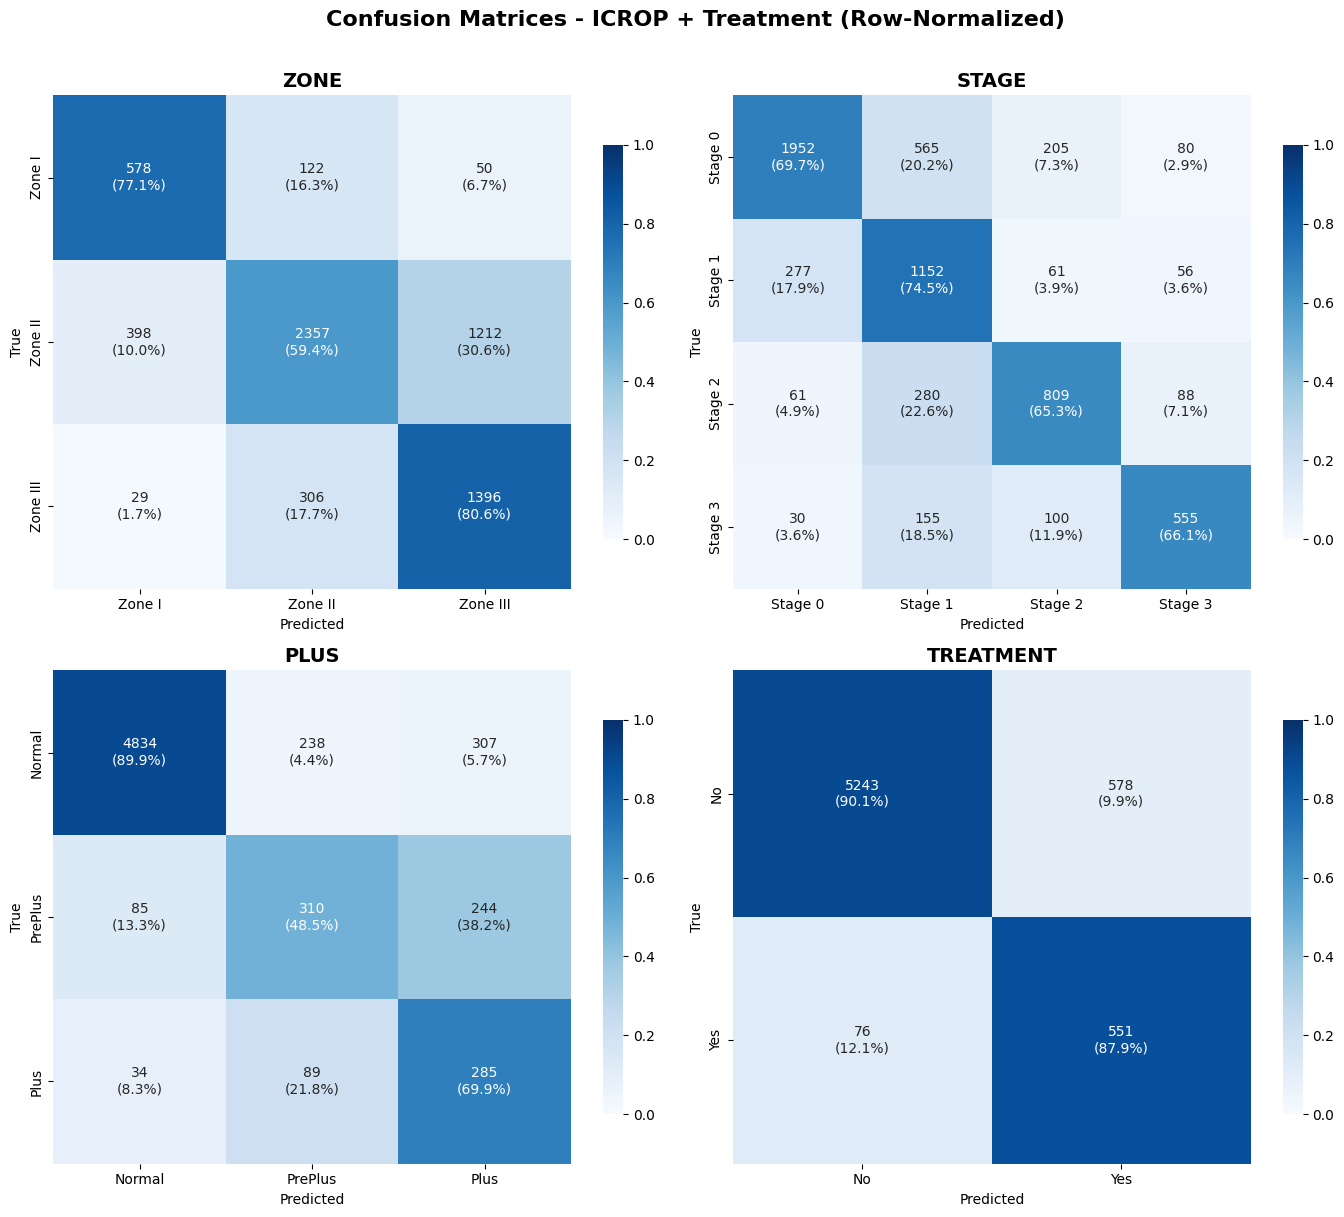

Saved to: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_icrop_treatment\confusion_matrices.png


In [19]:
# ==================== Confusion Matrix Visualization ====================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (task, class_map) in enumerate(task_class_names.items()):
    ax = axes[idx]
    y_true = pred_df[f'{task}_label'].values.astype(int)
    y_pred = pred_df[f'{task}_pred'].values.astype(int)

    mask = y_true >= 0
    y_true, y_pred = y_true[mask], y_pred[mask]

    classes = sorted(class_map.keys())
    labels = [class_map[c] for c in classes]
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.array([[f"{cnt}\n({pct:.1%})" for cnt, pct in zip(row_cnt, row_pct)]
                      for row_cnt, row_pct in zip(cm, cm_norm)])

    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', vmin=0, vmax=1,
                xticklabels=labels, yticklabels=labels, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{task.upper()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

fig.suptitle('Confusion Matrices - ICROP + Treatment (Row-Normalized)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {config.OUTPUT_DIR / 'confusion_matrices.png'}")

## 8. RW-ROP (Referral-Warranted ROP) Analysis

ICROP各タスクの予測値からRW-ROPを導出し、分類性能を評価する。

### RW-ROPの定義
以下の**いずれか**を含むROPをRW-ROP（紹介が必要なROP）と定義:
- **Plus disease** (Plus = 2)
- **Stage 3** (Stage = 3)
- **Zone I** (Zone = 0)

### RW-ROPスコアの算出方法
各タスクの予測確率から、独立性を仮定してRW-ROPの確率スコアを計算:

$$P(\text{RW-ROP}) = 1 - (1 - P(\text{Plus})) \times (1 - P(\text{Stage 3})) \times (1 - P(\text{Zone I}))$$

In [20]:
# ==================== RW-ROP Metrics ====================

from sklearn.metrics import roc_curve

pred_df = results['predictions_df']

# RW-ROP definition: Plus disease (plus=2) OR Stage 3 (stage=3) OR Zone I (zone=0)
pred_df['rw_rop_true'] = ((pred_df['plus_label'] == 2) |
                           (pred_df['stage_label'] == 3) |
                           (pred_df['zone_label'] == 0)).astype(int)
pred_df['rw_rop_pred'] = ((pred_df['plus_pred'] == 2) |
                           (pred_df['stage_pred'] == 3) |
                           (pred_df['zone_pred'] == 0)).astype(int)

# Probability-based RW-ROP score
# P(RW-ROP) = 1 - P(not Plus) * P(not Stage3) * P(not Zone I)
pred_df['rw_rop_prob'] = 1 - ((1 - pred_df['plus_prob_2']) *
                                (1 - pred_df['stage_prob_3']) *
                                (1 - pred_df['zone_prob_0']))

# Filter valid samples (all three labels must be valid)
valid_mask = ((pred_df['plus_label'] >= 0) &
              (pred_df['stage_label'] >= 0) &
              (pred_df['zone_label'] >= 0))
valid_df = pred_df[valid_mask].copy()

# Per-fold metrics
fold_metrics_list = []
for fold in sorted(valid_df['fold'].unique()):
    fold_data = valid_df[valid_df['fold'] == fold]
    y_true = fold_data['rw_rop_true'].values
    y_pred = fold_data['rw_rop_pred'].values
    y_prob = fold_data['rw_rop_prob'].values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    fold_metrics_list.append({
        'Fold': fold,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'PPV': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'F1': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0,
    })

fold_metrics_df = pd.DataFrame(fold_metrics_list)

print("=" * 70)
print("RW-ROP (Referral-Warranted ROP) Analysis")
print("=" * 70)
print(f"\nDefinition: Plus disease OR Stage 3 OR Zone I")
print(f"Total valid samples: {len(valid_df)}")
print(f"RW-ROP positive: {valid_df['rw_rop_true'].sum()} ({valid_df['rw_rop_true'].mean()*100:.1f}%)")
print(f"RW-ROP negative: {(1-valid_df['rw_rop_true']).sum()} ({(1-valid_df['rw_rop_true']).mean()*100:.1f}%)")

print(f"\nPer-fold Results:")
display(fold_metrics_df.round(4))

print(f"\nAggregated (Mean +/- SD):")
for metric in ['Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1', 'AUC-ROC']:
    mean = fold_metrics_df[metric].mean()
    std = fold_metrics_df[metric].std()
    print(f"  {metric:15s}: {mean:.4f} +/- {std:.4f}")

# Overall confusion matrix
y_true_all = valid_df['rw_rop_true'].values
y_pred_all = valid_df['rw_rop_pred'].values
cm_all = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
tn, fp, fn, tp = cm_all.ravel()
print(f"\nOverall Confusion Matrix:")
print(f"  {'':>12s}  Pred-   Pred+")
print(f"  {'True-':>12s}  {tn:>5}   {fp:>5}")
print(f"  {'True+':>12s}  {fn:>5}   {tp:>5}")

# Store for config
rw_rop_results = {}
for metric in ['Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1', 'AUC-ROC']:
    mean = fold_metrics_df[metric].mean()
    std = fold_metrics_df[metric].std()
    rw_rop_results[metric.lower().replace('-', '_')] = f"{mean:.4f} +/- {std:.4f}"

RW-ROP (Referral-Warranted ROP) Analysis

Definition: Plus disease OR Stage 3 OR Zone I
Total valid samples: 6426
RW-ROP positive: 1417 (22.1%)
RW-ROP negative: 5009 (77.9%)

Per-fold Results:


,Fold,Accuracy,Sensitivity,Specificity,PPV,NPV,F1,AUC-ROC
0,1,0.6824,0.6203,0.7005,0.3758,0.8639,0.4680,0.7007
1,2,0.9116,0.8808,0.9196,0.7387,0.9676,0.8035,0.9495
2,3,0.8993,0.7794,0.9580,0.9008,0.8986,0.8357,0.9167
3,4,0.8988,0.9213,0.8928,0.6930,0.9774,0.7910,0.9746
4,5,0.9396,0.8717,0.9507,0.7443,0.9783,0.8030,0.9798



Aggregated (Mean +/- SD):
  Accuracy       : 0.8663 +/- 0.1041
  Sensitivity    : 0.8147 +/- 0.1204
  Specificity    : 0.8843 +/- 0.1060
  PPV            : 0.6905 +/- 0.1927
  NPV            : 0.9372 +/- 0.0526
  F1             : 0.7402 +/- 0.1531
  AUC-ROC        : 0.9043 +/- 0.1165

Overall Confusion Matrix:
                Pred-   Pred+
         True-   4424     585
         True+    278    1139


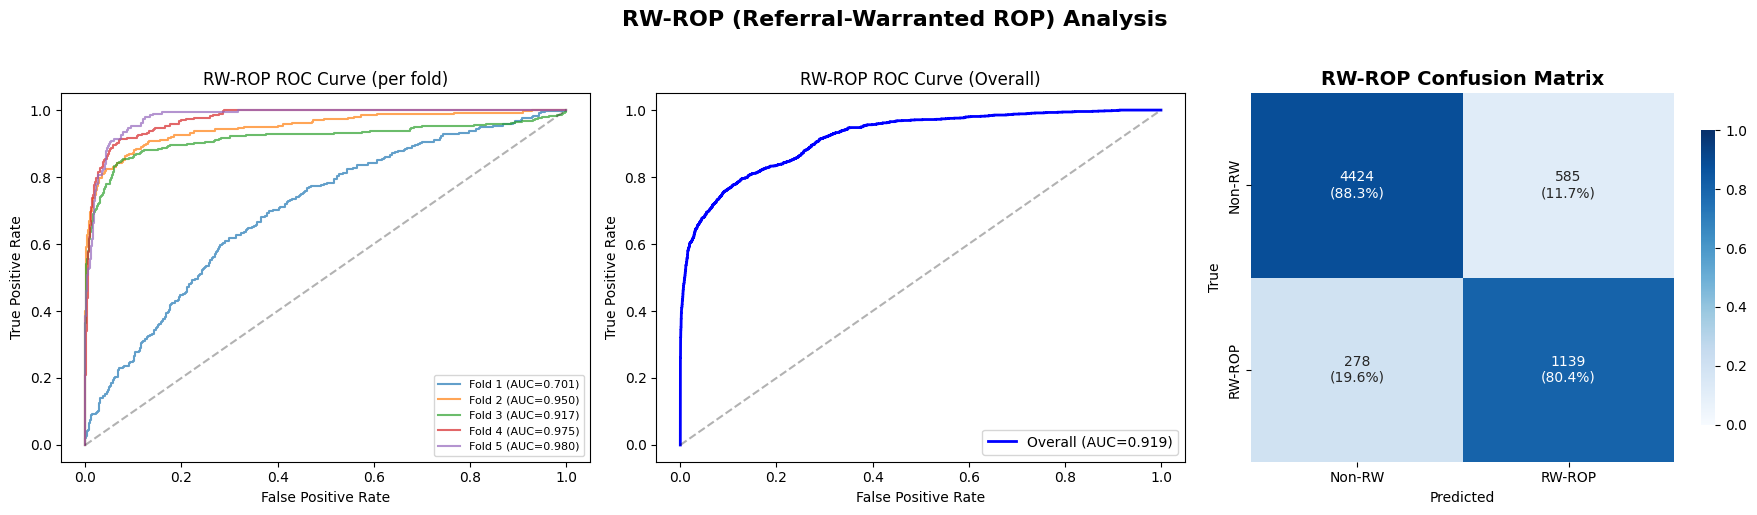

Saved to: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_icrop_treatment\rw_rop_analysis.png


In [21]:
# ==================== RW-ROP ROC Curve & Confusion Matrix ====================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per-fold ROC curves
ax = axes[0]
for fold in sorted(valid_df['fold'].unique()):
    fold_data = valid_df[valid_df['fold'] == fold]
    y_true = fold_data['rw_rop_true'].values
    y_prob = fold_data['rw_rop_prob'].values
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fold_auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'Fold {fold} (AUC={fold_auc:.3f})', alpha=0.7)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('RW-ROP ROC Curve (per fold)')
ax.legend(loc='lower right', fontsize=8)

# Overall ROC
ax = axes[1]
y_true_all = valid_df['rw_rop_true'].values
y_prob_all = valid_df['rw_rop_prob'].values
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
overall_auc = roc_auc_score(y_true_all, y_prob_all)
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Overall (AUC={overall_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('RW-ROP ROC Curve (Overall)')
ax.legend(loc='lower right')

# Confusion matrix heatmap
ax = axes[2]
cm_norm = cm_all.astype(float) / cm_all.sum(axis=1, keepdims=True)
annot = np.array([[f"{cnt}\n({pct:.1%})" for cnt, pct in zip(row_cnt, row_pct)]
                  for row_cnt, row_pct in zip(cm_all, cm_norm)])
sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', vmin=0, vmax=1,
            xticklabels=['Non-RW', 'RW-ROP'], yticklabels=['Non-RW', 'RW-ROP'],
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('RW-ROP Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')

plt.suptitle('RW-ROP (Referral-Warranted ROP) Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'rw_rop_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {config.OUTPUT_DIR / 'rw_rop_analysis.png'}")

In [22]:
# ==================== Save Configuration ====================

import json as json_lib

config_dict = {
    'version': config.VERSION,
    'model_name': config.MODEL_NAME,
    'quality_filter': config.QUALITY_FILTER,
    'n_clinical_features': config.N_CLINICAL_FEATURES,
    'clinical_embed_dim': config.CLINICAL_EMBED_DIM,
    'clinical_features': ['ga_value', 'bw_value', 'pma_value', 'sex_value'],
    'clinical_preprocessing': {
        'continuous': 'z-score per fold (ga, bw, pma)',
        'binary': 'raw 0/1 (sex)',
        'missing_continuous': 'median imputation (per fold)',
        'missing_sex': '0.5',
    },
    'use_class_weights': config.USE_CLASS_WEIGHTS,
    'use_focal_loss': config.USE_FOCAL_LOSS,
    'focal_gamma': config.FOCAL_GAMMA,
    'label_smoothing': config.LABEL_SMOOTHING,
    'class_weights': {k: v.tolist() for k, v in class_weights.items()},
    'results': {
        task: {metric: f"{mean:.4f} +/- {std:.4f}" for metric, (mean, std) in metrics.items()}
        for task, metrics in agg.items()
    },
    'rw_rop_results': rw_rop_results
}

with open(config.OUTPUT_DIR / 'config.json', 'w') as f:
    json_lib.dump(config_dict, f, indent=2)

print(f"Configuration saved to: {config.OUTPUT_DIR / 'config.json'}")

Configuration saved to: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_icrop_treatment\config.json
